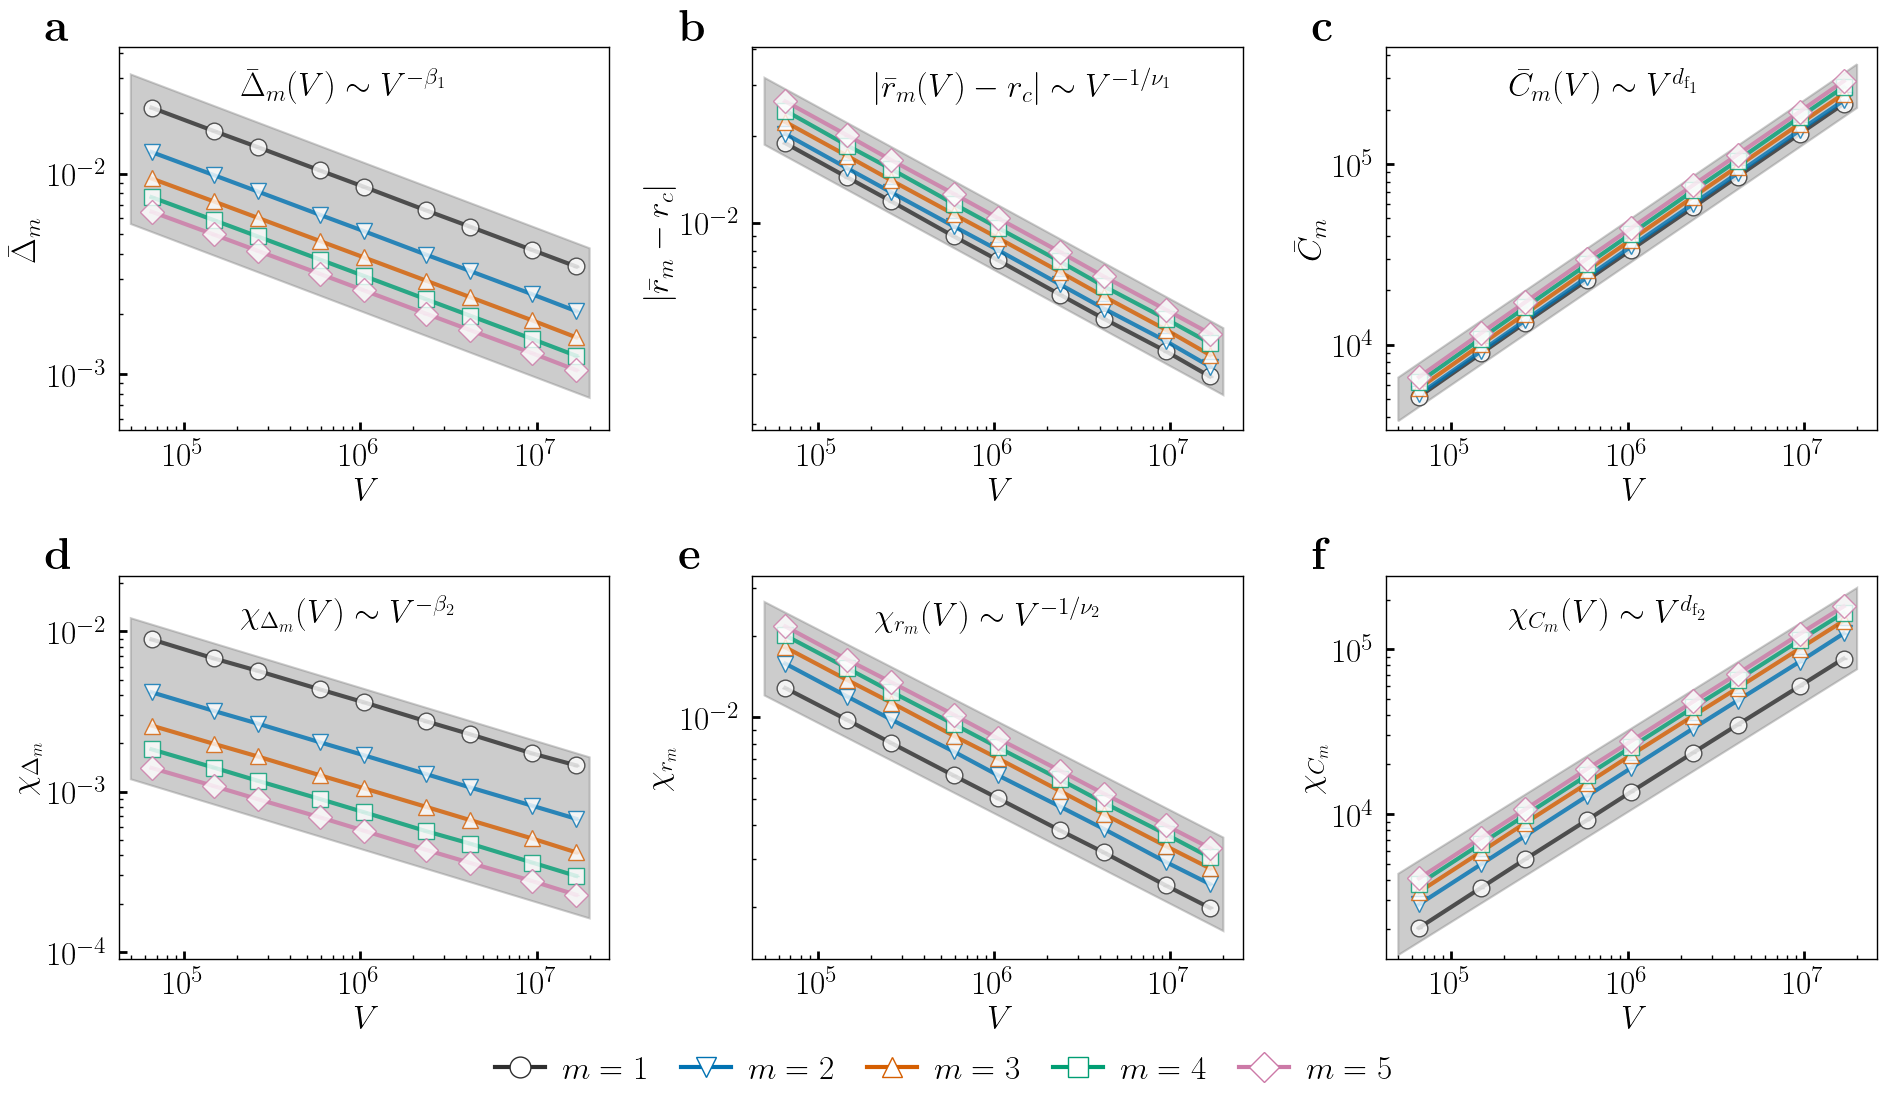

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
from matplotlib.ticker import LogFormatterMathtext
import matplotlib.patches as patches 
from matplotlib.lines import Line2D  # 需要导入Line2D
from matplotlib.ticker import LogLocator
# Figure setting  
#plt.rcParams['text.usetex'] = True 
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams.update({'font.size': 24})

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 24,  # Nature typically uses smaller fonts
    'axes.labelsize': 24,  # Slightly larger for axis labels
    'axes.titlesize': 24,  # For panel labels
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 24,
    'lines.linewidth': 2.5,
    'lines.markersize': 6,
    'axes.linewidth': 1.0,  # Thinner axes lines
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
})
figsize = (20, 12)
#ColorArr  = ['black', 'blue', 'red', 'orange', 'green']
# Nature-style color palette (colorblind-friendly)
ColorArr = ['#2E2E2E',  # Dark gray (almost black)
           '#0072B2',  # Blue
           '#D55E00',  # Vermillion
           '#009E73',  # Bluish green
           '#CC79A7']  # Reddish purple
MarkerArr = ['o', 'v', '^', 's', 'D']
MarSizArr = [12]*5
    
# Read File 
Curdir = os.getcwd() 
path1  = os.path.join(Curdir, "../data0/")
DatDir = os.path.normpath(path1) 

QuanArr = ['Dc', 'P', 'C', 'ChiDc', 'ChiP', 'ChiC']
VarYArr = ['$\\bar{\\Delta}_m$', '$|\\bar{r}_m -r_{c}|$', '$\\bar{C}_m$',
           '$\\chi_{\\Delta_m}$', '$\\chi_{{r}_m}$', '$\\chi_{C_m}$'] 

LabYArr = ['$\\bar{\\Delta}_m (V) \\sim V^{-\\beta_1}$', 
           '$|\\bar{r}_m(V) -r_{c}| \\sim V^{-1/\\nu_1}$', 
           '$\\bar{C}_m(V) \\sim V^{d_{\\mathrm{f}_1}} $',
           '$\\chi_{\\Delta_m}(V) \\sim V^{-\\beta_2}$',
           '$\\chi_{{r}_m}(V) \\sim V^{-1/\\nu_2} $',
           '$\\chi_{C_m}(V) \\sim V^{d_{\\mathrm{f}_2}}$'] 
# 创建2×3的子图网格
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for q1 in range(len(QuanArr)):
    qu1 = QuanArr[q1]
    FileArr = [os.path.join(DatDir, f"srt.{qu1}{s1}") for s1 in range(1,6)]
    
    ax = axes[q1]
    ax.set_xscale('log') 
    ax.set_yscale('log')

    # 设置主刻度加黑
    ax.tick_params(axis='x', which='major', direction='in', width=2, length=6, colors='black')
    ax.tick_params(axis='y', which='major', direction='in', width=2, length=6, colors='black')
    # 设置次刻度较细
    ax.tick_params(axis='x', which='minor', direction='in', width=1, length=3, colors='black')
    ax.tick_params(axis='y', which='minor', direction='in', width=1, length=3, colors='black')
    
    # 设置坐标轴标签
    ax.set_xlabel('$V$', fontsize=24)
    ylab = VarYArr[q1]
    ax.set_ylabel(ylab, fontsize=24)
    
    SelPoi = range(12,21)
    xmin = 1e12; xmax = 1e-12; ymin = 1e12; ymax = 1e-12

    for k in range(len(FileArr)):
        fname1 = FileArr[k]
        df1 = pd.read_csv(fname1, sep=r"\s+", header=None) 
        da1 = np.array(df1)
        x1 = da1[SelPoi,0]**2.0; y1 = da1[SelPoi,1]; yerr1 = da1[SelPoi, 2]
        if qu1 == "P":
            y1 = [abs(y11-0.5) for y11 in y1] 
        x1min = min(x1); x1max = max(x1); y1min = min(y1); y1max = max(y1)

        xmin = min(xmin, x1min)
        xmax = max(xmax, x1max)
        ymin = min(ymin, y1min)
        ymax = max(ymax, y1max)

#        ax.errorbar(x1, y1, yerr=yerr1, color=ColorArr[k], 
#                    marker=MarkerArr[k], markersize=MarSizArr[k], markerfacecolor=ColorArr[k],
#                    fillstyle='top', markeredgewidth=1, markeredgecolor=ColorArr[k],  
#                    linestyle='--', capsize=2, label=f'_nolegend_')
        ax.errorbar(x1, y1, yerr=yerr1, 
                    color=ColorArr[k],
                    marker=MarkerArr[k],
                    markersize=MarSizArr[k],
                    markerfacecolor='white',  # White fill for better visibility
                    fillstyle='full',
                    markeredgewidth=1.0,
                    markeredgecolor=ColorArr[k],
                    linestyle='-',  # Solid line for main plots
                    linewidth=3.0,
                    capsize=2.5,
                    capthick=1.0,
                    alpha=0.8,
                    label=f'$m={k+1}$')

    facx = 0.65; facy = facx
    if qu1 == "ChiDc":
        facy = 0.4
    if qu1 == "Dc":
        facy = 0.5
    ax.set_xlim(facx*xmin, 1.0/facx*xmax)
    ax.set_ylim(facy*ymin, 1.0/facy*ymax)
    ax.tick_params(axis='x', pad=8)
    ax.tick_params(axis='y', pad=8)

    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1, numticks=20))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1, numticks=20))

    # 设置主刻度
    ax.tick_params(axis='x', which='major', direction='in', width=2, length=6, colors='black', labelsize=24)
    ax.tick_params(axis='y', which='major', direction='in', width=2, length=6, colors='black', labelsize=24)
    # 设置次刻度
    ax.tick_params(axis='x', which='minor', direction='in', width=1, length=3, colors='black')
    ax.tick_params(axis='y', which='minor', direction='in', width=1, length=3, colors='black')

    # fillfac
    fillfile = os.path.join(DatDir, f"fill{qu1}.dat")
    if os.path.exists(fillfile):
        df2 = pd.read_csv(fillfile, sep=r"\s+", header=None)
        da2 = np.array(df2)
        points = np.array(da2)
        polygon = patches.Polygon(points, closed=True, alpha=0.4, color='gray', linewidth=1.5)
        ax.add_patch(polygon)

    # 添加标号 - 放在图外面左上角，黑体加粗
    label_text = chr(97 + q1)
    ax.text(-0.15, 1.10, r'$\mathbf{' + label_text +'}$', transform=ax.transAxes, 
            fontsize=32, fontweight='bold', verticalalignment='top', horizontalalignment='left')

    ax.text(0.25, 0.95, LabYArr[q1], transform=ax.transAxes, 
            fontsize=24, fontweight='bold', verticalalignment='top', horizontalalignment='left')

# 创建图例元素
#legend_elements = [Line2D([0], [0], marker=MarkerArr[k], color=ColorArr[k], 
#                   markerfacecolor=ColorArr[k], markersize=MarSizArr[k] + 2,  # 稍微增大图例中的标记大小
#                   fillstyle='top', markeredgewidth=1, markeredgecolor=ColorArr[k], 
#                   linestyle='None', label=f'$m={k+1}$') for k in range(5)]

legend_elements = []
for k in range(5):
    legend_elements.append(
        Line2D([0], [0], 
               marker=MarkerArr[k], 
               color=ColorArr[k],
               markerfacecolor='white',
               markersize=MarSizArr[k] + 3,
               fillstyle='full',
               markeredgewidth=1.0,
               markeredgecolor=ColorArr[k],
               linestyle='-',
               linewidth=3.0,
               label=f'$m={k+1}$')
    )

# 将图例放在图的最下面，横向排列
fig.legend(handles=legend_elements,
           loc='lower center',           # 放在底部中央
           bbox_to_anchor=(0.5, 0.02),   # 调整垂直位置
           ncol=5,                       # 横向排列，5列
           fontsize=24,                  # 图例字体大小
           frameon=False,                # 显示图例框
           fancybox=True,                # 圆角边框
           shadow=False,                 # 无阴影
           handletextpad=0.5,            # 标记和文本间距
           columnspacing=1.0,            # 列间距
           handlelength=1.5)             # 标记长度

# 调整子图间距，为底部图例留出空间
plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=1.0)
plt.subplots_adjust(bottom=0.15)  # 增加底部边距，为图例留出空间

plt.savefig("Fig1.svg")

plt.show()